In [10]:
import json
import pickle
from random import random
from collections import Counter
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from rdkit import Chem

from HADES.featurize import Featurizer
from HADES.correlation_drop import CorrDrop
from HADES.ml_modeling import HPOptimizer
featurizer = Featurizer()


/home/narek/.local/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/narek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/narek/.local/lib/python3.10/site-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detail

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

/home/narek/.local/lib/python3.10/site-packages/chemprop/utils.py:418: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=lambda storage, lo

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

In [11]:
df=pd.read_csv(r'initial_data_for_HADES_pipeline.csv')
smiles = df['SMILES']

In [12]:
data_featurized = featurizer.featurize_many_smiles(smiles)
print(f'All features data shape: {data_featurized.shape}')
na_dropped_data = featurizer.drop_na_cols(data_featurized)
same_val_dropped_data = featurizer.drop_same_val_cols(na_dropped_data)
print(f'Invalid features dropped shape: {same_val_dropped_data.shape}')

  0%|          | 21/8106 [00:02<09:57, 13.54it/s] 

/home/narek/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  7%|▋         | 606/8106 [00:30<09:49, 12.72it/s]

/home/narek/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/narek/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  8%|▊         | 671/8106 [00:32<06:12, 19.97it/s]

...

/home/narek/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 14%|█▎        | 1105/8106 [00:57<08:26, 13.81it/s]

/home/narek/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


individual models:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/163 [00:00<?, ?it/s]

  1%|          | 1/163 [00:00<00:21,  7.58it/s]

  2%|▏         | 3/163 [00:00<00:16,  9.60it/s]

  3%|▎         | 5/163 [00:00<00:13, 11.67it/s]

  4%|▍         | 7/163 [00:00<00:11, 13.23it/s]

  6%|▌         | 9/163 [00:00<00:11, 13.14it/s]

  7%|▋         | 11/163 [00:00<00:11, 12.78it/s]

  8%|▊         | 13/163 [00:01<00:12, 12.33it/s]

  9%|▉         | 15/163 [00:01<00:11, 13.09it/s]

 10%|█         | 17/163 [00:01<00:11, 12.46it/s]

 12%|█▏        | 19/163 [00:01<00:11, 13.02it/s]

 13%|█▎        | 21/163 [00:01<00:11, 11.90it/s]

 14%|█▍        | 23/163 [00:01<00:11, 11.86it/s]

 15%|█▌        | 25/163 [00:02<00:10, 12.60it/s]

 17%|█▋        | 27/163 [00:02<00:10, 12.60it/s]

 18%|█▊        | 29/163 [00:02<00:15,  8.53it/s]

 19%|█▉        | 31/163 [00:02<00:18,  7.22it/s]

 20%|██        | 33/163 [00:03<00:15,  8.33it/s]

 21%|██▏       | 35/163 [00:03<00:13,  9.73it/s]

 23%|█

All features data shape: (8106, 1666)
Invalid features dropped shape: (8106, 966)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(same_val_dropped_data, df['phase'], random_state=42,
													test_size=0.2)

In [14]:
X_train.columns = X_train.columns.astype(str)

In [9]:
import time
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import os
import gc   # ✅ add this at the top


# Create folder if it doesn't exist
output_dir = "seed_dependency"
# os.makedirs(output_dir, exist_ok=True)
#
seeds = [42,1,23,100,97,38,305,294,3001,9]

for seed in seeds:
    start_time = time.time()
    print(f"\nRun of {seed} seed...")

    model = RandomForestClassifier(
        n_estimators=1000,
        n_jobs=-1,
        random_state=seed
    )

    corrdrop = CorrDrop(model)

    cv_thresh_dict, cv_thresh_std_dict = corrdrop.get_corr_threshold(X_train, y_train)

    threshold_results = pd.DataFrame({
        "threshold": list(cv_thresh_dict.keys()),
        "accuracy_mean": list(cv_thresh_dict.values()),
        "accuracy_std": [cv_thresh_std_dict[t] for t in cv_thresh_dict.keys()]
    }).sort_values("threshold", ascending=False)

    # Save threshold results
    threshold_results.to_csv(
        os.path.join(output_dir, f"cv_results_{seed}.csv"),
        index=False
    )

    keep_cols, opt_threshold = corrdrop.get_cols_to_keep(
        X_train,
        cv_thresh_dict,
        cv_thresh_std_dict
    )

    # Save kept features (include seed in filename to avoid overwrite)
    pd.DataFrame({"kept_features": keep_cols}).to_csv(
        os.path.join(output_dir, f"kept_features_{seed}.csv"),
        index=False
    )

    end_time = time.time()
    print(f"Run {seed} finished in {end_time - start_time:.2f} seconds")

        # ✅ ADD CLEANUP HERE (end of loop)
    del model, corrdrop, cv_thresh_dict, cv_thresh_std_dict
    del threshold_results, keep_cols

    gc.collect()


Run of 23 seed...


100%|██████████| 99/99 [1:15:41<00:00, 45.87s/it]


Run 23 finished in 4560.48 seconds

Run of 100 seed...


100%|██████████| 99/99 [1:15:27<00:00, 45.73s/it]


Run 100 finished in 4546.54 seconds

Run of 97 seed...


...

Run 294 finished in 4552.47 seconds

Run of 3001 seed...


100%|██████████| 99/99 [1:15:28<00:00, 45.74s/it]


Run 3001 finished in 4547.51 seconds

Run of 9 seed...


100%|██████████| 99/99 [1:15:28<00:00, 45.74s/it]


Run 9 finished in 4547.45 seconds


In [32]:
import pandas as pd
import os

# List of seed numbers (edit as needed)
seeds = [42, 1, 23,100,97,38,305,294,3001,9]

kept_features_dict = {}

for seed in seeds:
    filename = f'./seed_dependency/kept_features_{seed}.csv'

    if os.path.exists(filename):  # Optional safety check
        df = pd.read_csv(filename)

        if 'kept_features' in df.columns:
            kept_features_dict[seed] = df['kept_features']
        else:
            print(f"'kept_features' column not found in {filename}")
    else:
        print(f"{filename} does not exist")

# Now your dictionary looks like:
# {5: Series, 10: Series, 15: Series, ...}

In [33]:
all_kept_features = [v.tolist() if hasattr(v, "tolist") else v
                     for v in kept_features_dict.values()]

In [34]:
[len(i) for i in all_kept_features]

[298, 208, 298, 310, 298, 230, 264, 310, 298, 275]

In [21]:
X_train

,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,VE3_A,...,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,ALOGP,HBA,HBD,PSA,ROTB,AROM,ALERTS
5782,0,29.900932,2.474869,4.933951,29.900932,1.196037,4.135236,4.317353,0.172694,2.378933,...,61.258894,-2.385298,11.990604,2.82062,4,0,66.65,7,1,1
7957,0,36.905913,2.402373,4.804745,36.905913,1.272618,4.281885,4.794673,0.165334,2.632216,...,89.989139,-3.899995,6.645746,2.66760,6,2,113.99,4,3,3
6760,1,22.174260,2.476680,4.687041,22.174260,1.304368,3.798325,3.701886,0.217758,1.839471,...,47.139570,-2.355870,5.477520,2.92030,2,0,12.47,2,0,0
7222,1,21.670381,2.594488,5.036532,21.670381,1.274728,3.835409,3.709297,0.218194,1.841471,...,46.828211,-1.697031,-1.439967,0.59490,4,0,54.22,2,0,2
6223,4,22.582285,2.469555,4.823885,22.582285,1.328370,3.789113,3.779047,0.222297,1.860100,...,-0.964264,-0.961653,2.188528,-0.52910,4,3,71.67,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,0,35.757468,2.515836,5.031672,35.757468,1.277052,4.256688,4.327574,0.154556,2.494626,...,81.201120,-2.736526,-2.445731,-0.68540,7,5,147.40,4,2,2
5390,0,26.073336,2.426602,4.819054,26.073336,1.133623,4.032848,4.218040,0.183393,2.272280,...,51.464274,-2.016205,2.758931,-0.27482,6,1,118.78,7,0,0
860,0,45.698923,2.621459,5.197589,45.698923,1.235106,4.569020,4.605778,0.124480,2.835644,...,105.711947,-6.434674,6.690980,6.57610,2,2,58.20,2,1,1
7603,0,28.741955,2.323979,4.647959,28.741955,1.249650,4.034330,4.005886,0.174169,2.220674,...,77.507505,-4.599401,9.521981,2.00698,5,1,81.91,5,2,0


In [23]:
from scipy.spatial.distance import squareform
corr_matrix = X_train.corr()
distance_matrix = 1 - np.abs(corr_matrix)
condensed_dist = squareform(distance_matrix.values, checks=False)

In [24]:
condensed_dist

array([0.94188879, 0.82166   , 0.86031067, ..., 0.70092685, 0.80889964,
       0.80533312])

In [74]:
from rdkit.ML.Cluster import Butina

# Set threshold (important parameter!)
cutoff = 0.2   # smaller = tighter clusters

clusters = Butina.ClusterData(
    condensed_dist,
    nPts=len(distance_matrix),
    distThresh=cutoff,
    isDistData=True
)

print(len(clusters))

66


In [75]:
feature_names = corr_matrix.columns.astype(str)


clustered_features = [
    [feature_names[i] for i in cluster]
    for cluster in clusters
]

for i, cluster in enumerate(clustered_features):
    print(f"Cluster {i+1}: {cluster}")

Cluster 1: ['MPC9', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDiam_A', 'nAtom', 'nHeavyAtom', 'nC', 'nN', 'nO', 'ATS0dv', 'ATS1dv', 'ATS2dv', 'ATS8dv', 'ATS0d', 'ATS1d', 'ATS3d', 'ATS8d', 'ATS0s', 'ATS2s', 'ATS3s', 'ATS4s', 'ATS5s', 'ATS6s', 'ATS7s', 'ATS7are', 'ATS8are', 'ATS0p', 'ATS1p', 'ATS2p', 'ATS3p', 'ATS4p', 'ATS6p', 'ATS7p', 'ATS8p', 'ATS0i', 'ATS1i', 'ATS2i', 'ATS3i', 'ATS4i', 'ATS5i', 'ATS6i', 'ATS7i', 'ATS8i', 'AATS1dv', 'AATS2dv', 'AATS3dv', 'AATS4dv', 'AATS0d', 'AATS1d', 'AATS2d', 'AATS3d', 'AATS4d', 'AATS0s', 'AATS1s', 'AATS2s', 'AATS4s', 'AATS0Z', 'AATS1Z', 'AATS2Z', 'AATS3Z', 'AATS4Z', 'AATS0m', 'AATS1m', 'AATS2m', 'AATS3m', 'AATS4m', 'AATS0v', 'AATS2v', 'AATS3v', 'AATS4v', 'AATS0se', 'AATS1se', 'AATS2se', 'AATS3se', 'AATS4se', 'AATS0pe', 'AATS1pe', 'AATS2pe', 'AATS3pe', 'AATS0are', 'AATS1are', 'AATS2are', 'AATS3are', 'AATS4are', 'AATS0p', 'AATS1p', 'AATS2p', 'AATS3p', 'AATS4p', 'AATS1i', 'AATS3i', 'AATS4i', 'ATSC0dv', 'ATSC1dv', 'ATSC2dv', 'ATSC3dv', 'ATSC4dv', 'ATSC5dv', 'AT

In [76]:
cluster_dict = {
    f"Cluster {i+1}": cluster
    for i, cluster in enumerate(clustered_features)
}

In [77]:
feature_to_cluster_num = {}

for cluster_name, features in cluster_dict.items():
    cluster_num = int(cluster_name.split()[-1])  # extract number

    for feat in features:
        feature_to_cluster_num[feat] = cluster_num

In [78]:
cluster_number_lists = [
    [feature_to_cluster_num[f] for f in feature_list if f in feature_to_cluster_num]
    for feature_list in all_kept_features
]

In [79]:
[len(i) for i in (cluster_number_lists)]
# cluster_number_lists[0]

[298, 208, 298, 310, 298, 230, 264, 310, 298, 275]

In [80]:
from collections import Counter
cluster_number_lists_to_dict = [dict(Counter(i)) for i in cluster_number_lists ]

In [81]:
import numpy as np

def build_matrix(dict_list):
    n = len(dict_list)
    matrix = np.zeros((n, n), dtype=float)

    for i in range(n):
        keys_i = set(dict_list[i].keys())
        len_i = len(keys_i)

        for j in range(n):
            if i == j:
                matrix[i][j] = 1.0  # full overlap with itself
            else:
                keys_j = set(dict_list[j].keys())
                intersection = len(keys_i & keys_j)
                matrix[i][j] = intersection / len_i if len_i != 0 else 0.0

    return matrix


# usage

# usage
matrix = build_matrix(cluster_number_lists_to_dict)
dfffff = pd.DataFrame(matrix)

In [82]:
import numpy as np

unique_values = sorted(np.unique(dfffff.values))
print(unique_values)

[0.7735849056603774, 0.7884615384615384, 0.7924528301886793, 0.82, 0.8461538461538461, 0.8490566037735849, 0.8666666666666667, 0.88, 0.9069767441860465, 0.9230769230769231, 0.9245283018867925, 0.9433962264150944, 0.9534883720930233, 0.96, 0.9615384615384616, 0.9767441860465116, 0.9777777777777777, 0.98, 0.9811320754716981, 1.0]


In [2]:
import numpy as np
np.mean([0.7735849056603774, 0.7884615384615384, 0.7924528301886793, 0.82, 0.8461538461538461, 0.8490566037735849, 0.8666666666666667, 0.88, 0.9069767441860465, 0.9230769230769231, 0.9245283018867925, 0.9433962264150944, 0.9534883720930233, 0.96, 0.9615384615384616, 0.9767441860465116, 0.9777777777777777, 0.98, 0.9811320754716981, 1.0]),np.std([0.7735849056603774, 0.7884615384615384, 0.7924528301886793, 0.82, 0.8461538461538461, 0.8490566037735849, 0.8666666666666667, 0.88, 0.9069767441860465, 0.9230769230769231, 0.9245283018867925, 0.9433962264150944, 0.9534883720930233, 0.96, 0.9615384615384616, 0.9767441860465116, 0.9777777777777777, 0.98, 0.9811320754716981, 1.0])

(0.9052517729698512, 0.07109067059609192)

In [42]:
import pandas as pd
from collections import Counter
import os

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------
seeds = [42, 1, 23, 100, 97, 38, 305, 294, 3001, 9]
balanced_folder = "./seed_depenndency_balanced/"
unbalanced_folder = "./seed_dependency/"

# -------------------------------------------------
# HELPER: LOAD KEPT FEATURES PER SEED
# -------------------------------------------------
def load_kept_features(folder, seeds):
    kept_features_dict = {}
    for seed in seeds:
        filename = f"{folder}/kept_features_{seed}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            if "kept_features" in df.columns:
                kept_features_dict[seed] = df['kept_features'].tolist()
            else:
                print(f"'kept_features' column not found in {filename}")
        else:
            print(f"{filename} does not exist")
    return kept_features_dict

balanced_features = load_kept_features(balanced_folder, seeds)
unbalanced_features = load_kept_features(unbalanced_folder, seeds)

# -------------------------------------------------
# CONVERT FEATURE LISTS TO CLUSTER NUMBERS
# -------------------------------------------------
def features_to_cluster_numbers(features_dict, feature_to_cluster_num):
    """
    Converts each seed's features into a dictionary of cluster numbers with counts.
    Returns a dict: {seed: {cluster_num: count, ...}, ...}
    """
    seed_cluster_dict = {}
    for seed, feature_list in features_dict.items():
        cluster_numbers = [feature_to_cluster_num[f]
                           for f in feature_list if f in feature_to_cluster_num]
        seed_cluster_dict[seed] = dict(Counter(cluster_numbers))
    return seed_cluster_dict

# -------------------------------------------------
# APPLY TO BALANCED AND UNBALANCED
# -------------------------------------------------
# feature_to_cluster_num must be defined from your clustering step
# Example: feature_to_cluster_num = {'feat1':1, 'feat2':1, 'feat3':2, ...}

balanced_seed_clusters = features_to_cluster_numbers(balanced_features, feature_to_cluster_num)
unbalanced_seed_clusters = features_to_cluster_numbers(unbalanced_features, feature_to_cluster_num)

# -------------------------------------------------
# EXAMPLE OUTPUT
# -------------------------------------------------
for seed in seeds:
    print(f"\nSeed {seed} (Balanced): {balanced_seed_clusters[seed]}")
    print(f"Seed {seed} (Unbalanced): {unbalanced_seed_clusters[seed]}")


Seed 42 (Balanced): {1: 117, 2: 39, 6: 16, 3: 38, 4: 22, 7: 6, 28: 3, 29: 2, 23: 2, 10: 5, 14: 1, 5: 1, 38: 1, 15: 4, 9: 3, 13: 3, 30: 1, 41: 1, 43: 1, 51: 1, 57: 1, 65: 1, 60: 1, 8: 7, 22: 2, 12: 2, 42: 1, 18: 3, 49: 1, 25: 1, 40: 1, 59: 1, 47: 1, 44: 1, 55: 1, 34: 1, 21: 1, 45: 1, 50: 1, 54: 1, 35: 1, 46: 1, 20: 1, 62: 1, 66: 1, 56: 1, 53: 1, 33: 1, 64: 1, 61: 1, 24: 1, 19: 1, 27: 1}
Seed 42 (Unbalanced): {1: 113, 2: 30, 6: 20, 3: 36, 13: 5, 4: 17, 5: 4, 7: 4, 28: 3, 29: 2, 23: 4, 10: 5, 14: 1, 38: 1, 15: 5, 9: 3, 30: 1, 41: 1, 43: 1, 51: 1, 57: 1, 65: 1, 60: 1, 8: 6, 12: 2, 42: 1, 18: 3, 49: 1, 25: 1, 40: 1, 59: 1, 47: 1, 44: 1, 55: 1, 34: 1, 21: 1, 45: 1, 22: 1, 50: 1, 54: 1, 35: 1, 46: 1, 20: 1, 62: 1, 66: 1, 56: 1, 53: 1, 64: 1, 61: 1, 24: 1, 19: 1, 11: 1, 27: 1}

Seed 1 (Balanced): {1: 117, 2: 39, 6: 16, 3: 38, 4: 22, 7: 6, 28: 3, 29: 2, 23: 2, 10: 5, 14: 1, 5: 1, 38: 1, 15: 4, 9: 3, 13: 3, 30: 1, 41: 1, 43: 1, 51: 1, 57: 1, 65: 1, 60: 1, 8: 7, 22: 2, 12: 2, 42: 1, 18: 3, 49: 1

In [45]:
import numpy as np

# -------------------------------------------------
# HELPER: convert cluster dict to vector
# -------------------------------------------------
def cluster_dict_to_vector(cluster_dict, all_clusters):
    """
    Converts a dictionary of {cluster_num: count} to a vector over all clusters
    """
    return np.array([cluster_dict.get(c, 0) for c in all_clusters], dtype=float)

# -------------------------------------------------
# GET ALL CLUSTERS
# -------------------------------------------------
all_clusters = sorted(set().union(
    *[d.keys() for d in balanced_seed_clusters.values()],
    *[d.keys() for d in unbalanced_seed_clusters.values()]
))

# -------------------------------------------------
# CALCULATE CORRELATION PER SEED
# -------------------------------------------------
seed_correlations = {}

for seed in seeds:
    balanced_vec = cluster_dict_to_vector(balanced_seed_clusters[seed], all_clusters)
    unbalanced_vec = cluster_dict_to_vector(unbalanced_seed_clusters[seed], all_clusters)

    # Pearson correlation
    if np.std(balanced_vec) == 0 or np.std(unbalanced_vec) == 0:
        corr = np.nan  # avoid division by zero
    else:
        corr = np.corrcoef(balanced_vec, unbalanced_vec)[0, 1]

    seed_correlations[seed] = corr

# -------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------
for seed, corr in seed_correlations.items():
    print(f"Seed {seed}: correlation between balanced and unbalanced clusters = {corr:.3f}")

Seed 42: correlation between balanced and unbalanced clusters = 0.996
Seed 1: correlation between balanced and unbalanced clusters = 0.995
Seed 23: correlation between balanced and unbalanced clusters = 0.992
Seed 100: correlation between balanced and unbalanced clusters = 1.000
Seed 97: correlation between balanced and unbalanced clusters = 0.996
Seed 38: correlation between balanced and unbalanced clusters = 0.997
Seed 305: correlation between balanced and unbalanced clusters = 0.997
Seed 294: correlation between balanced and unbalanced clusters = 1.000
Seed 3001: correlation between balanced and unbalanced clusters = 1.000
Seed 9: correlation between balanced and unbalanced clusters = 0.995


In [10]:
import pandas as pd
df = pd.read_csv(r'seed_dependency/cv_results_42.csv')

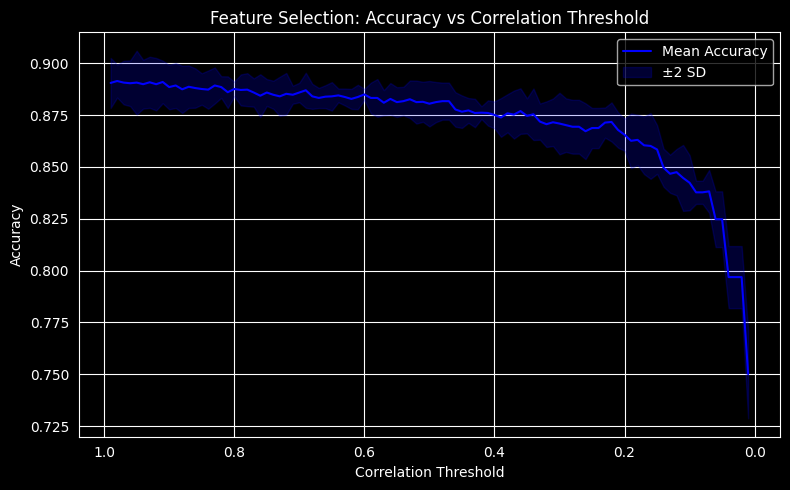

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Example dataframe

# Calculate upper and lower bounds for ±2 standard deviations
df['upper'] = df['accuracy_mean'] + 2 * df['accuracy_std']
df['lower'] = df['accuracy_mean'] - 2 * df['accuracy_std']

# Plot
plt.figure(figsize=(8,5))
plt.plot(df['threshold'], df['accuracy_mean'], color='blue', label='Mean Accuracy')
plt.fill_between(df['threshold'], df['lower'], df['upper'], color='blue', alpha=0.2, label='±2 SD')
plt.xlabel('Correlation Threshold')
plt.ylabel('Accuracy')
plt.title('Feature Selection: Accuracy vs Correlation Threshold')
plt.gca().invert_xaxis()  # Optional: higher thresholds on the left
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure
plt.savefig('feature_selection_accuracy_plot.png', dpi=300)
plt.show()